In [2]:
import pandas as pd

df = pd.read_csv("datasets/Student_Performance.csv")
df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## Understanding Correlation and the Heatmap

### What is Correlation?
Correlation measures the **relationship between two variables**. It answers: "When one variable increases, does the other variable tend to increase, decrease, or stay the same?"

### Correlation Coefficient (The Numbers)
- **Range**: -1 to +1
- **+1**: Perfect positive correlation (both increase together)
- **0**: No correlation (one variable's change doesn't affect the other)
- **-1**: Perfect negative correlation (one increases while the other decreases)

### How to Interpret the Numbers:
- **0.90 - 1.00**: Very strong relationship
- **0.70 - 0.89**: Strong relationship
- **0.50 - 0.69**: Moderate relationship
- **0.30 - 0.49**: Weak relationship
- **0.00 - 0.29**: Very weak/no relationship

### The Heatmap Colors:
- **Dark Red**: Strong positive correlation → Variables move together
- **White/Light**: No correlation → Variables are independent
- **Dark Blue**: Strong negative correlation → Variables move opposite

### What This Means for Your Data:
The diagonal always shows 1.0 (each variable perfectly correlates with itself). The key insight is **Previous Scores has 0.92 correlation with Performance Index** — this is very strong! It means:
- Students with high previous scores tend to have high performance index
- This is your **most important feature** for predicting performance

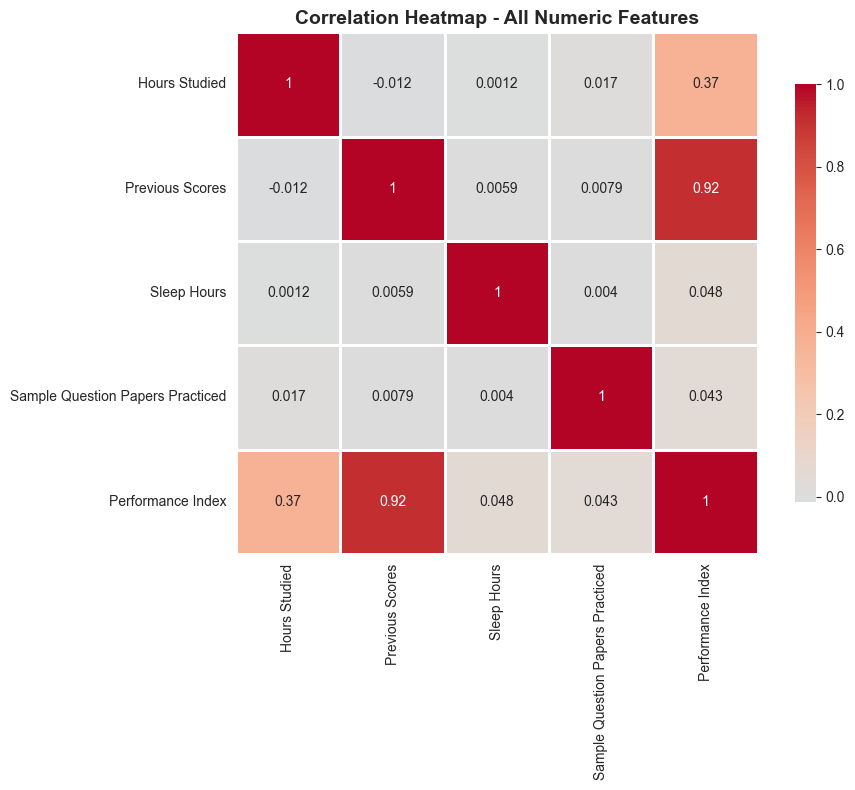

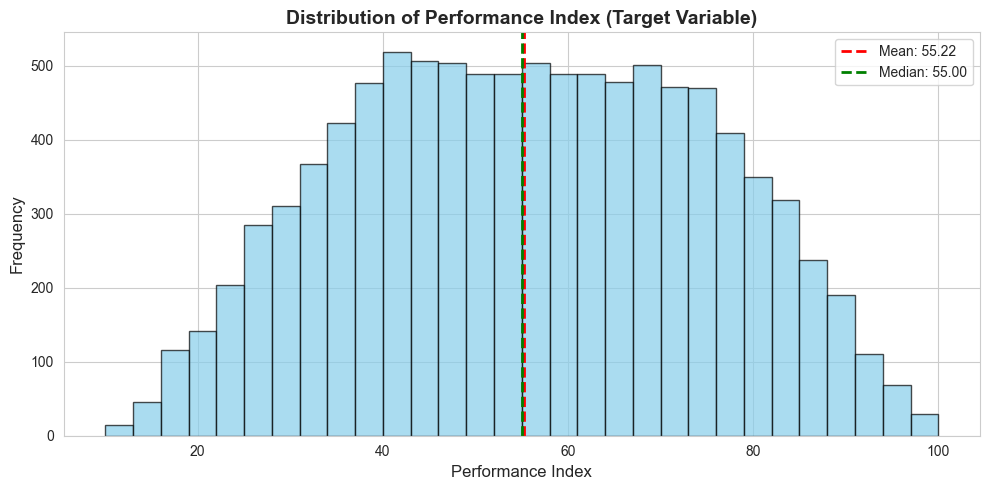

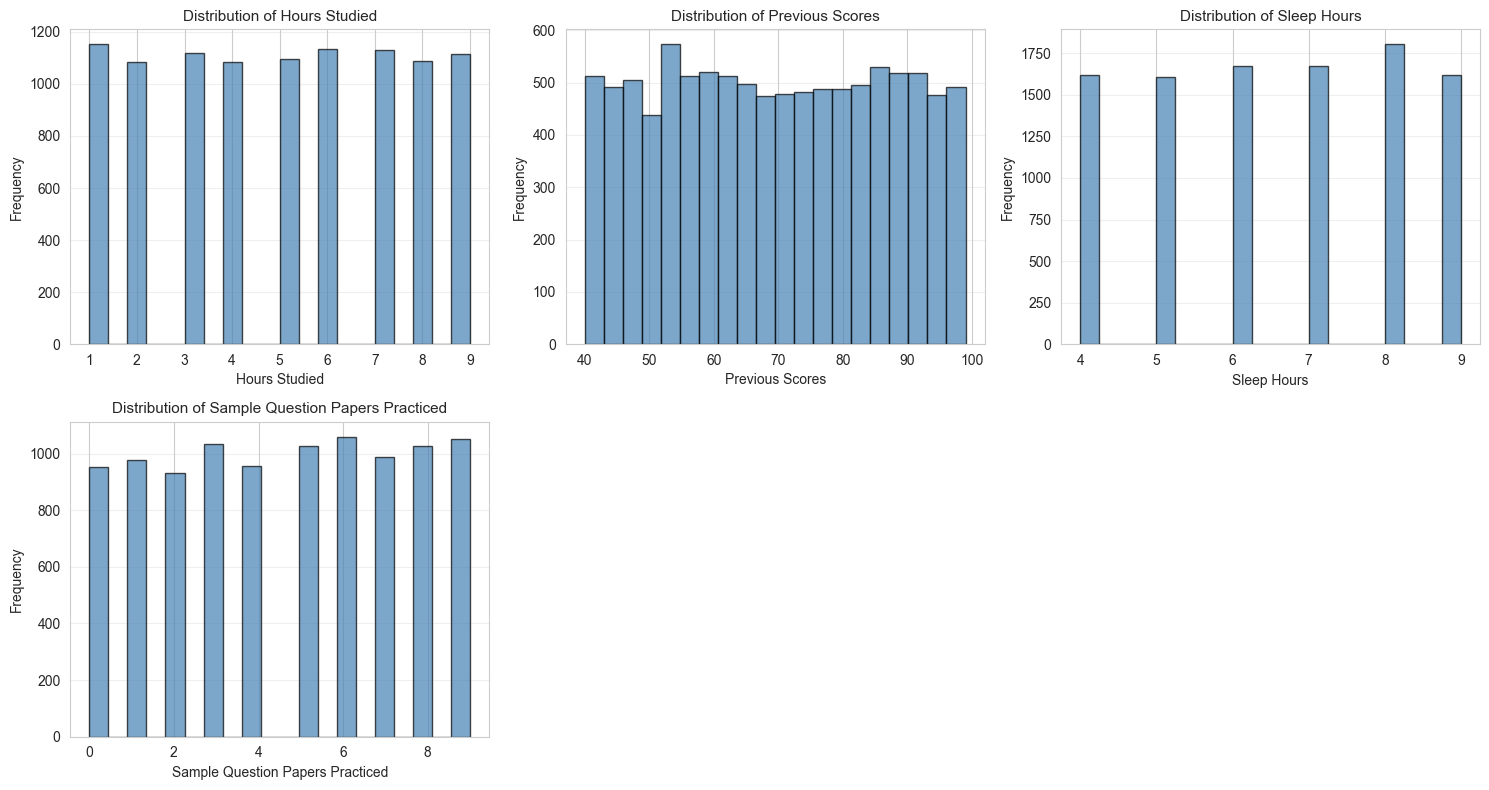


=== Performance Index Summary Statistics ===
count    10000.000000
mean        55.224800
std         19.212558
min         10.000000
25%         40.000000
50%         55.000000
75%         71.000000
max        100.000000
Name: Performance Index, dtype: float64


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# 1. Correlation Heatmap
plt.figure(figsize=(10, 8))
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap - All Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. Histogram of Target Variable (Performance Index)
plt.figure(figsize=(10, 5))
plt.hist(df['Performance Index'].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('Performance Index', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Performance Index (Target Variable)', fontsize=14, fontweight='bold')
plt.axvline(df['Performance Index'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Performance Index"].mean():.2f}')
plt.axvline(df['Performance Index'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Performance Index"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

# 3. Histograms for all feature variables
numeric_features = [col for col in numeric_df.columns if col != 'Performance Index']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].set_title(f'Distribution of {col}', fontsize=11)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove extra subplots
for idx in range(len(numeric_features), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Print summary statistics for target variable
print("\n=== Performance Index Summary Statistics ===")
print(df['Performance Index'].describe())

In [9]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

df['Extracurricular Activities'].value_counts()

Extracurricular Activities
0    5052
1    4948
Name: count, dtype: int64

In [15]:
print("\n" + "="*60)
print("ENCODING MAPPING:")
print("="*60)
print(f"'No' is encoded as: {le.transform(['No'])[0]}")
print(f"'Yes' is encoded as: {le.transform(['Yes'])[0]}")
print("\nClasses (in alphabetical order):", le.classes_)
print("="*60)


ENCODING MAPPING:
'No' is encoded as: 0
'Yes' is encoded as: 1

Classes (in alphabetical order): ['No' 'Yes']


## Task 2: Data Preprocessing & Splitting

✅ **Encoding Complete**: Extracurricular Activities encoded to 0/1
- 0 = No
- 1 = Yes

Now we'll split the data into 80% training and 20% testing sets.

In [10]:
from sklearn.model_selection import train_test_split

# Prepare features (X) and target (y)
X = df.drop('Performance Index', axis=1)  # All features except target
y = df['Performance Index']  # Target variable

# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("="*60)
print("DATA SPLIT RESULTS (80/20)")
print("="*60)
print(f"\nTotal samples: {len(df)}")
print(f"\nTraining set (80%):")
print(f"  - X_train shape: {X_train.shape}")
print(f"  - y_train shape: {y_train.shape}")
print(f"\nTest set (20%):")
print(f"  - X_test shape: {X_test.shape}")
print(f"  - y_test shape: {y_test.shape}")

print(f"\nPerformance Index Statistics:")
print(f"  Training set - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"  Test set - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")
print("="*60)

# Display first few rows of training data
print("\nFirst 5 rows of training data (X_train):")
print(X_train.head())
print("\nCorresponding target values (y_train):")
print(y_train.head())

DATA SPLIT RESULTS (80/20)

Total samples: 10000

Training set (80%):
  - X_train shape: (8000, 5)
  - y_train shape: (8000,)

Test set (20%):
  - X_test shape: (2000, 5)
  - y_test shape: (2000,)

Performance Index Statistics:
  Training set - Mean: 55.31, Std: 19.20
  Test set - Mean: 54.88, Std: 19.26

First 5 rows of training data (X_train):
      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
9254              5               49                           0            7   
1561              2               48                           1            7   
1670              2               81                           0            7   
6087              2               46                           0            6   
6669              8               47                           0            9   

      Sample Question Papers Practiced  
9254                                 5  
1561                                 6  
1670                                 2  
6

## Task 3: Model Evaluation on Train/Test Split

Why use the split data?
- **Training data**: Teach the model
- **Test data**: Check if it generalizes to new, unseen data
- **Without this**: You can't know if your model just memorized the training data!

## 명확한 워크플로우

### Step 1: 데이터 분리 (이미 했음 ✅)
```
전체 데이터 10,000개
    ↓
X_train (8,000개) + y_train (8,000개)  ← 학습용
X_test (2,000개) + y_test (2,000개)    ← 평가용
```

### Step 2: 모델 학습 (이제 할거)
```
ONLY X_train + y_train으로 모델을 만든다!
model = train(X_train, y_train)
```

### Step 3: 평가 (왜 두 개를 다 봐야 함?)
```
만든 모델에게 말한다:
"너가 본 데이터(X_train)에서는 얼마나 잘 맞아?"  → y_train_pred vs y_train
"너가 안 본 새로운 데이터(X_test)에서는 얼마나 잘 맞아?" → y_test_pred vs y_test
```

### 왜 둘 다 봐야 하나?
- ❌ Training만 좋으면 = 데이터를 "외웠을" 가능성 (overfitting)
- ✅ Training과 Test 둘 다 좋으면 = 진짜 학습한 것 (generalization)

In [28]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# ============================================================================
# STEP 1: 모델 학습 (Training data X_train, y_train으로만 학습!)
# ============================================================================
df_train = df.iloc[X_train.index].copy()

train_model = sm.ols("Q('Performance Index') ~ Q('Hours Studied') + Q('Previous Scores') + Q('Extracurricular Activities') + Q('Sleep Hours') + Q('Sample Question Papers Practiced')", 
                     data=df_train).fit()

print("\n" + "="*70)
print("✅ STEP 1: 모델 학습 완료 (8,000개 학습 데이터 사용)")
print("="*70)
print(train_model.summary())



✅ STEP 1: 모델 학습 완료 (8,000개 학습 데이터 사용)
                              OLS Regression Results                              
Dep. Variable:     Q('Performance Index')   R-squared:                       0.989
Model:                                OLS   Adj. R-squared:                  0.989
Method:                     Least Squares   F-statistic:                 1.398e+05
Date:                    Mon, 19 Jan 2026   Prob (F-statistic):               0.00
Time:                            21:17:21   Log-Likelihood:                -17063.
No. Observations:                    8000   AIC:                         3.414e+04
Df Residuals:                        7994   BIC:                         3.418e+04
Df Model:                               5                                         
Covariance Type:                nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
-------------------------

In [22]:
# ============================================================================
# STEP 2: 두 데이터셋 모두에서 예측 만들기
# ============================================================================
# 학습한 모델이 "본 데이터"(training)에서 얼마나 잘 맞는지?
y_train_pred = train_model.predict(df_train)

# 학습한 모델이 "본 적 없는 새로운 데이터"(test)에서 얼마나 잘 맞는지?
y_test_pred = train_model.predict(df.iloc[X_test.index])

print("\n" + "="*70)
print("✅ STEP 2: 예측 완료")
print("   - Training 데이터에 대한 예측: y_train_pred")
print("   - Test 데이터에 대한 예측: y_test_pred")
print("="*70)


✅ STEP 2: 예측 완료
   - Training 데이터에 대한 예측: y_train_pred
   - Test 데이터에 대한 예측: y_test_pred


In [23]:

# ============================================================================
# STEP 3: 성능 비교
# ============================================================================
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)


print("\n" + "="*70)
print("✅ STEP 3: 성능 비교")
print("="*70)
print(f"\n{'Metric':<20} {'Training (80%)':<20} {'Test (20%)':<20}")
print("-" * 70)
print(f"{'R² Score':<20} {train_r2:<20.4f} {test_r2:<20.4f}")
print(f"{'RMSE':<20} {train_rmse:<20.4f} {test_rmse:<20.4f}")
print(f"{'MAE':<20} {train_mae:<20.4f} {test_mae:<20.4f}")
print("="*70)

print("\n✅ 해석:")
if abs(train_r2 - test_r2) < 0.05:
    print("   ✓ 모델이 WELL GENERALIZE됨 - Training과 Test 성능이 비슷!")
    print("   ✓ 모델이 데이터를 '외운' 게 아니라 진짜 '배운' 것!")
elif test_r2 < train_r2:
    print(f"   ⚠ 약간의 overfitting 있음 (차이: {train_r2-test_r2:.4f})")
    print("   하지만 여전히 Test 성능이 좋음 - 괜찮은 모델!")


✅ STEP 3: 성능 비교

Metric               Training (80%)       Test (20%)          
----------------------------------------------------------------------
R² Score             0.9887               0.9890              
RMSE                 2.0420               2.0206              
MAE                  1.6193               1.6111              

✅ 해석:
   ✓ 모델이 WELL GENERALIZE됨 - Training과 Test 성능이 비슷!
   ✓ 모델이 데이터를 '외운' 게 아니라 진짜 '배운' 것!


## Diagnostic Plots: Residual Analysis & Q-Q Plot

These plots help us check if our model assumptions are valid:
- **Residual Plot**: Are errors random? (should have no pattern)
- **Q-Q Plot**: Are errors normally distributed? (should follow the diagonal line)

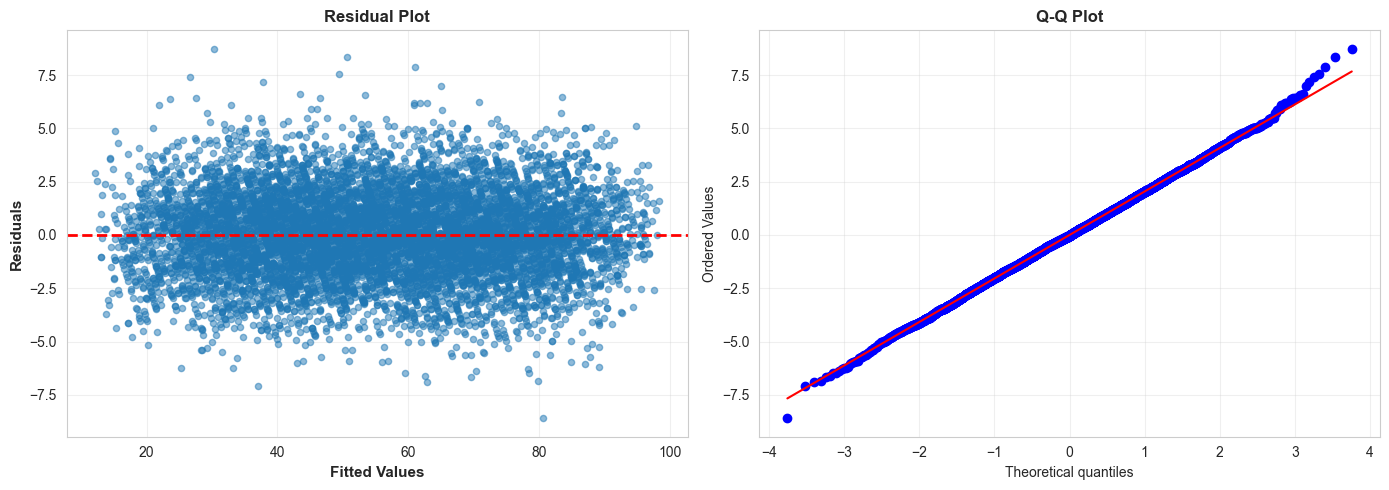

In [25]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Calculate residuals (actual - predicted)
residuals = y_train - y_train_pred

# Create a 1x2 figure with only Residual and Q-Q plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ============================================================================
# Plot 1: Residuals vs Fitted Values
# ============================================================================
axes[0].scatter(y_train_pred, residuals, alpha=0.5, s=20)
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Fitted Values', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=11, fontweight='bold')
axes[0].set_title('Residual Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# ============================================================================
# Plot 2: Q-Q Plot (Normal Probability Plot)
# ============================================================================
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Task 5: Making Predictions

### The Regression Equation (Linear Regression Function)

Based on our trained model, the equation to predict Performance Index is:

```
Performance Index = -34.0756 + (2.8530 × Hours Studied) + (1.0184 × Previous Scores) + 
                    (0.6129 × Extracurricular Activities) + (0.4806 × Sleep Hours) + 
                    (0.1938 × Sample Question Papers Practiced)
```

**Where:**
- **Hours Studied**: hours per week (1-9)
- **Previous Scores**: previous exam score (40-100)
- **Extracurricular Activities**: 0 = No, 1 = Yes
- **Sleep Hours**: hours per night (4-9)
- **Sample Question Papers Practiced**: number of papers (0-9)

In [40]:
import pandas as pd

# ============================================================================
# Show P-VALUES from the Model
# ============================================================================
print("\n" + "="*70)
print("MODEL COEFFICIENT P-VALUES")
print("="*70)
p_values = train_model.pvalues
for var, pval in p_values.items():
    print(f"  {var:<40} p-value: {pval:.2e}")
print(f"\nHIGHEST P-VALUE: {p_values.max():.2e}")
print("="*70)

# ============================================================================
# Use ACTUAL MEAN VALUES from training data (not arbitrary defaults)
# ============================================================================
print("\n" + "="*70)
print("DEFAULT VALUES FROM TRAINING DATA MEANS")
print("="*70)
print(f"  Previous Scores (mean): {df_train['Previous Scores'].mean():.2f}")
print(f"  Extracurricular Activities (mode): {df_train['Extracurricular Activities'].mode().values[0]:.0f}")
print(f"  Sample Papers (mean): {df_train['Sample Question Papers Practiced'].mean():.2f}")
print("="*70)




MODEL COEFFICIENT P-VALUES
  Intercept                                p-value: 0.00e+00
  Q('Hours Studied')                       p-value: 0.00e+00
  Q('Previous Scores')                     p-value: 0.00e+00
  Q('Extracurricular Activities')          p-value: 4.69e-40
  Q('Sleep Hours')                         p-value: 6.44e-256
  Q('Sample Question Papers Practiced')    p-value: 3.12e-123

HIGHEST P-VALUE: 4.69e-40

DEFAULT VALUES FROM TRAINING DATA MEANS
  Previous Scores (mean): 69.53
  Extracurricular Activities (mode): 0
  Sample Papers (mean): 4.62


In [41]:
student_data = pd.DataFrame({
    'Hours Studied': [10],
    'Previous Scores': [df_train['Previous Scores'].mean()],  # Using actual mean
    'Extracurricular Activities': [int(df_train['Extracurricular Activities'].mode().values[0])],  # Using mode
    'Sleep Hours': [8],
    'Sample Question Papers Practiced': [df_train['Sample Question Papers Practiced'].mean()]  # Using actual mean
})

# Make prediction using the trained model
predicted_score = train_model.predict(student_data)

print("\n" + "="*70)
print("TASK 5: PREDICTION")
print("="*70)
print("\nStudent Profile:")
print(f"  Hours Studied: {student_data['Hours Studied'].values[0]:.0f} (VARIABLE)")
print(f"  Sleep Hours: {student_data['Sleep Hours'].values[0]:.0f} (VARIABLE)")
print(f"  Previous Scores: {student_data['Previous Scores'].values[0]:.2f} (training mean)")
print(f"  Extracurricular Activities: {'Yes' if student_data['Extracurricular Activities'].values[0] == 1 else 'No'} (training mode)")
print(f"  Sample Papers Practiced: {student_data['Sample Question Papers Practiced'].values[0]:.2f} (training mean)")

print("\n" + "-"*70)
print(f"\nPredicted Performance Index: {predicted_score[0]:.2f}")
print("="*70)



TASK 5: PREDICTION

Student Profile:
  Hours Studied: 10 (VARIABLE)
  Sleep Hours: 8 (VARIABLE)
  Previous Scores: 69.53 (training mean)
  Extracurricular Activities: No (training mode)
  Sample Papers Practiced: 4.62 (training mean)

----------------------------------------------------------------------

Predicted Performance Index: 70.02
